In [2]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
CSV_DIR = "/Users/raymondwang/racecar_docker/home/racecar_ws/src/lab6/data_viz/csv_output"

print(CSV_DIR)

/Users/raymondwang/racecar_docker/home/racecar_ws/src/lab6/data_viz/csv_output


In [5]:
# CSV_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "csv_output")
CSV_DIR = os.path.join(os.getcwd(), "csv_output")


dfs = {}
for fname in sorted(os.listdir(CSV_DIR)):
    if fname.endswith(".csv"):
        name = os.path.splitext(fname)[0]
        dfs[name] = pd.read_csv(os.path.join(CSV_DIR, fname), low_memory=False)
        print(f"{name}: {len(dfs[name])} rows, {len(dfs[name].columns)} columns")

print(f"\nLoaded {len(dfs)} file(s).")

corner1: 6876 rows, 148 columns
corner2: 4037 rows, 148 columns
corner3: 3535 rows, 148 columns
s1: 7394 rows, 148 columns
s2: 4953 rows, 148 columns
s3: 4526 rows, 148 columns
sim_test2: 8088 rows, 148 columns

Loaded 7 file(s).


In [7]:
def parse_points(points_str):
    """Parse a stringified list of geometry_msgs Point objects into (xs, ys)."""
    xs = [float(v) for v in re.findall(r'x=([-\d.e+]+)', points_str)]
    ys = [float(v) for v in re.findall(r'y=([-\d.e+]+)', points_str)]
    return xs, ys


def _trim(df, t_start, t_end):
    """Return rows within [t_start, t_end] seconds from the first timestamp."""
    t0 = df["timestamp"].min()
    return df[(df["timestamp"] >= t0 + t_start) & (df["timestamp"] <= t0 + t_end)]


def plot_paths(df, name, t_start=0, t_end=None):
    if t_end is None:
        t_end = df["timestamp"].max() - df["timestamp"].min()
    df = _trim(df, t_start, t_end)
    fig, ax = plt.subplots(figsize=(8, 6))

    # --- Actual pose ---
    actual = df[df["topic"] == "/pf/pose"].dropna(subset=["pf.pose.pose.position.x"])
    ax.plot(
        actual["pf.pose.pose.position.x"],
        actual["pf.pose.pose.position.y"],
        label="Actual pose", linewidth=1.5, color="steelblue"
    )

    # --- Planned trajectory ---
    planned_rows = df[df["topic"] == "/planned_trajectory/path"].dropna(
        subset=["planned_trajectory.path.points"]
    )
    for _, row in planned_rows.iterrows():
        xs, ys = parse_points(row["planned_trajectory.path.points"])
        ax.plot(xs, ys, label="Planned path", linewidth=1.5,
                linestyle="--", color="tomato")

    # --- Followed trajectory ---
    followed_rows = df[df["topic"] == "/followed_trajectory/path"].dropna(
        subset=["followed_trajectory.path.points"]
    )
    for _, row in followed_rows.iterrows():
        xs, ys = parse_points(row["followed_trajectory.path.points"])
        ax.plot(xs, ys, label="Followed path", linewidth=1.5,
                linestyle=":", color="seagreen")

    ax.set_title(f"{name} (t={t_start}s – {t_end}s)")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_y_vs_time(df, name, t_start=0, t_end=None):
    if t_end is None:
        t_end = df["timestamp"].max() - df["timestamp"].min()
    df = _trim(df, t_start, t_end)
    actual = df[df["topic"] == "/pf/pose"].dropna(subset=["pf.pose.pose.position.y"])
    t0 = actual["timestamp"].min()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(actual["timestamp"] - t0, actual["pf.pose.pose.position.y"],
            linewidth=1.5, color="steelblue")

    ax.set_title(f"{name} — y vs time (t={t_start}s – {t_end}s)")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("y (m)")
    plt.tight_layout()
    plt.show()

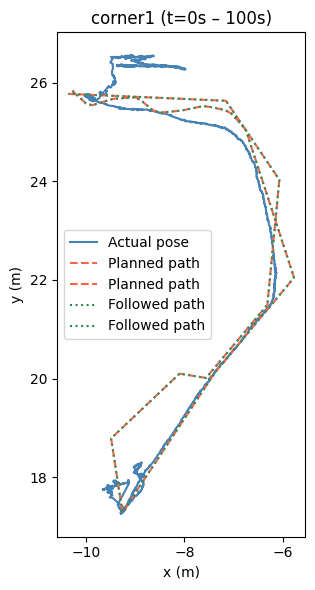

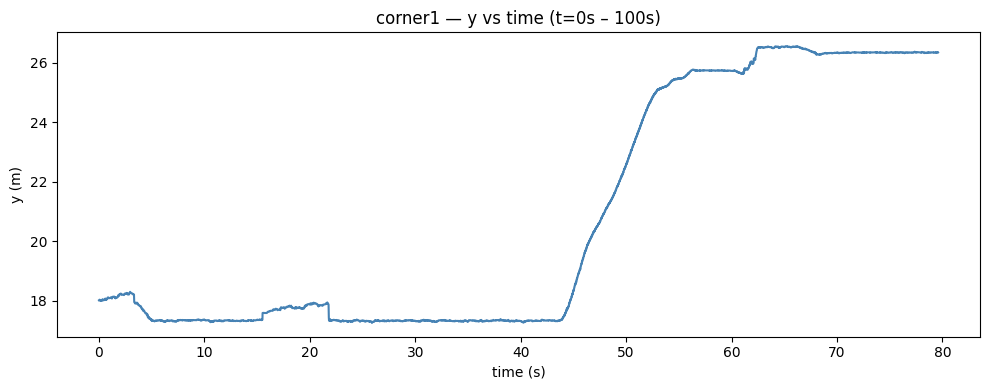

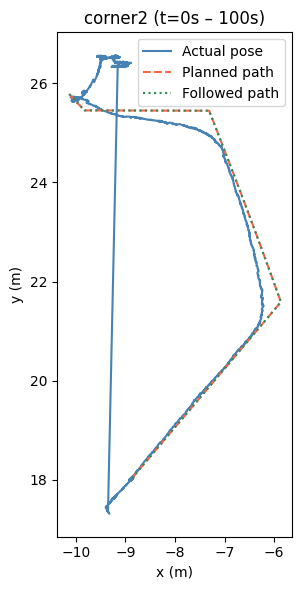

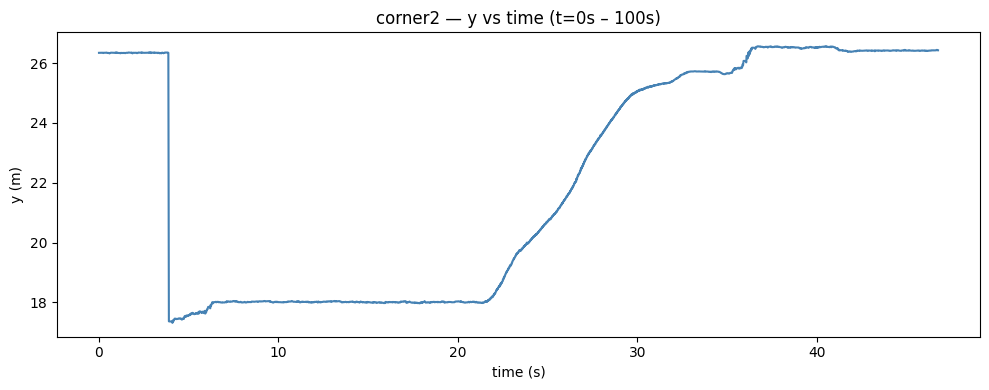

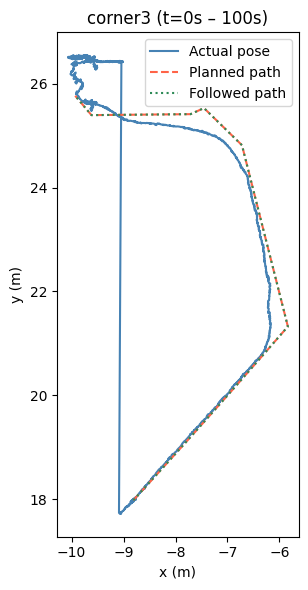

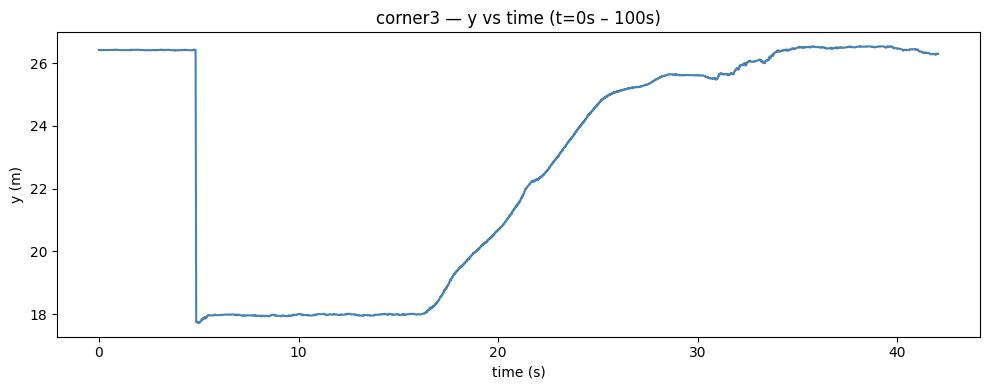

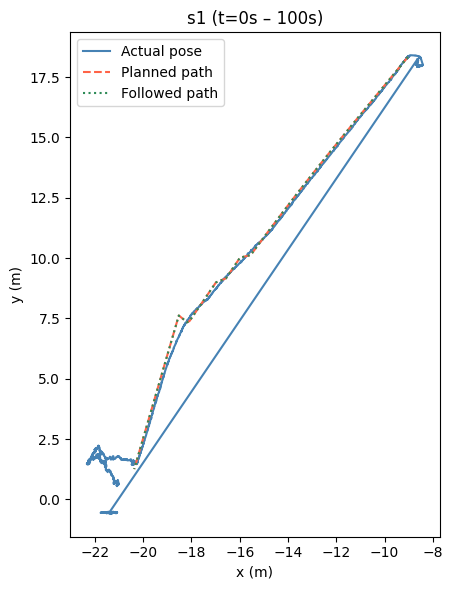

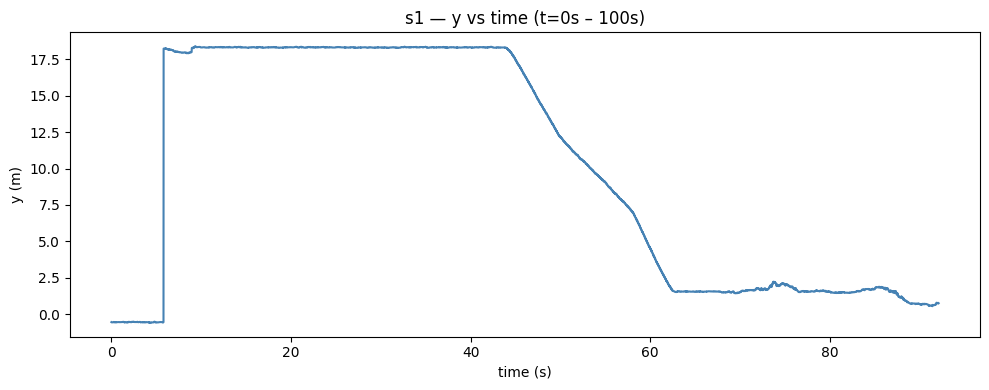

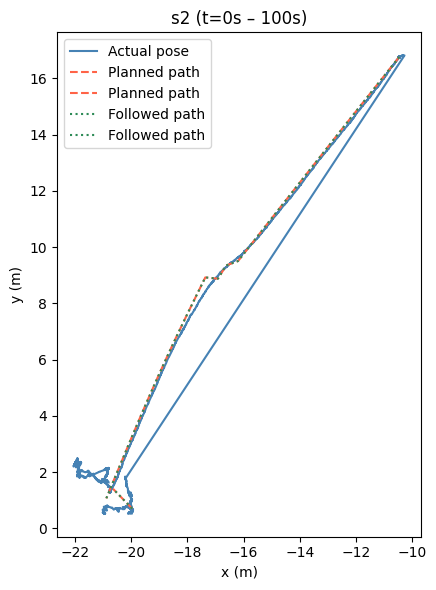

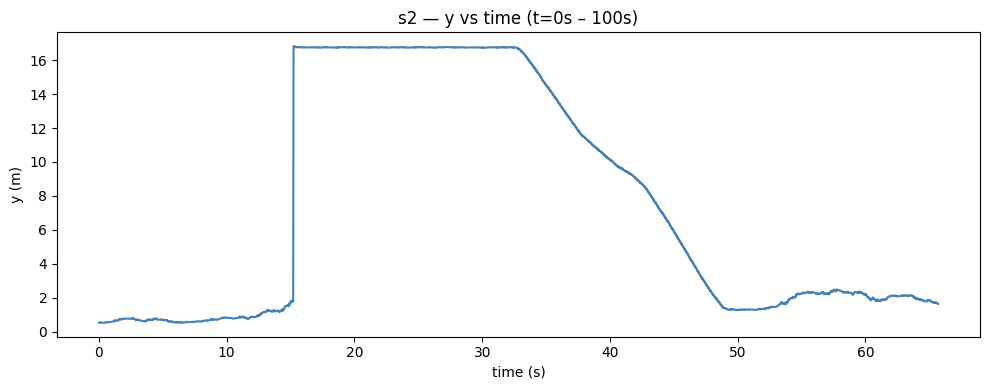

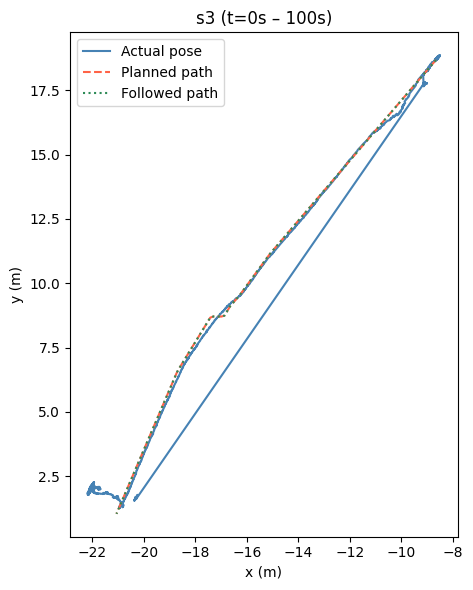

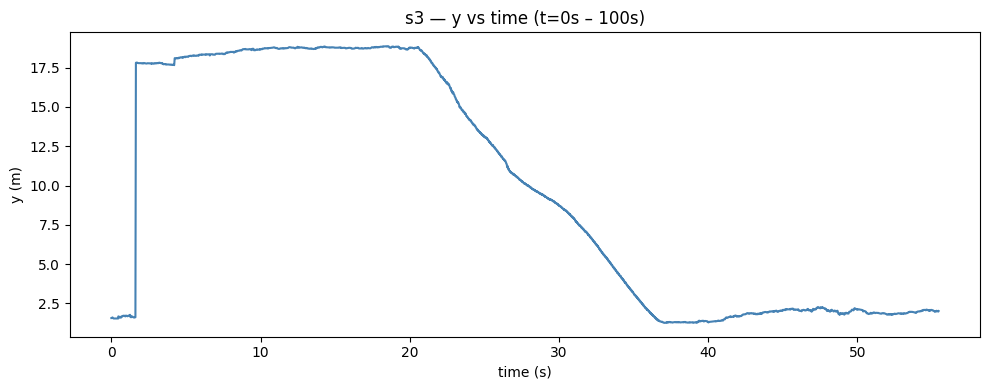

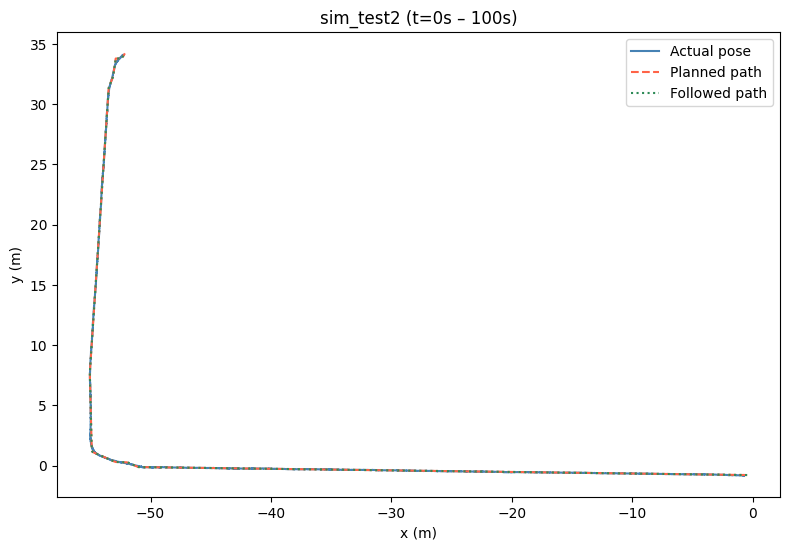

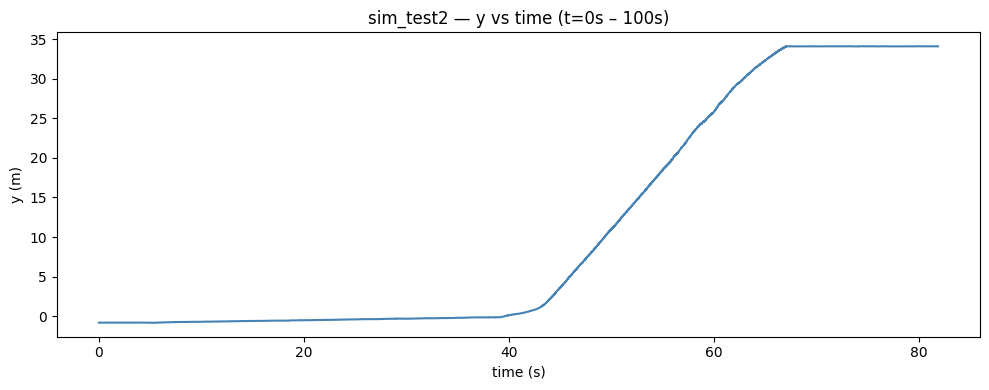

In [8]:
T_START = 0   # seconds from start of trial
T_END   = 100  # seconds from start of trial

for name, df in dfs.items():
    plot_paths(df, name, t_start=T_START, t_end=T_END)
    plot_y_vs_time(df, name, t_start=T_START, t_end=T_END)

In [9]:
import numpy as np

def _point_to_segment_dist(px, py, ax, ay, bx, by):
    """Perpendicular distance from point (px,py) to segment (ax,ay)-(bx,by)."""
    dx, dy = bx - ax, by - ay
    seg_len_sq = dx*dx + dy*dy
    if seg_len_sq == 0:
        return np.hypot(px - ax, py - ay)
    t = np.clip(((px - ax)*dx + (py - ay)*dy) / seg_len_sq, 0, 1)
    return np.hypot(px - (ax + t*dx), py - (ay + t*dy))


def _cte_for_pose(pose_x, pose_y, path_xs, path_ys):
    """Min distance from each pose point to the nearest segment of the path."""
    path_xs, path_ys = np.array(path_xs), np.array(path_ys)
    dists = np.array([
        _point_to_segment_dist(px, py, path_xs[i], path_ys[i], path_xs[i+1], path_ys[i+1])
        for px, py in zip(pose_x, pose_y)
        for i in range(len(path_xs) - 1)
    ]).reshape(len(pose_x), len(path_xs) - 1)
    return dists.min(axis=1)


def calc_avg_cte(names, t_start, t_end):
    """
    Calculate average cross-track error for each CSV name in `names` between
    t_start and t_end seconds (relative to the start of each trial).
    CTE is the perpendicular distance from each actual pose point to the
    nearest segment of the followed trajectory path.
    """
    results = {}
    for name in names:
        if name not in dfs:
            print(f"  [skip] '{name}' not in loaded CSVs")
            continue

        df = _trim(dfs[name], t_start, t_end)

        # Get followed path points
        followed_rows = df[df["topic"] == "/followed_trajectory/path"].dropna(
            subset=["followed_trajectory.path.points"]
        )
        if followed_rows.empty:
            print(f"  [skip] '{name}' has no followed trajectory data in this window")
            continue
        path_xs, path_ys = parse_points(followed_rows.iloc[0]["followed_trajectory.path.points"])
        if len(path_xs) < 2:
            print(f"  [skip] '{name}' followed path has fewer than 2 points")
            continue

        # Get actual poses
        actual = df[df["topic"] == "/pf/pose"].dropna(
            subset=["pf.pose.pose.position.x", "pf.pose.pose.position.y"]
        )
        if actual.empty:
            print(f"  [skip] '{name}' has no pose data in this window")
            continue

        cte = _cte_for_pose(
            actual["pf.pose.pose.position.x"].values,
            actual["pf.pose.pose.position.y"].values,
            path_xs, path_ys
        )
        avg_cte = cte.mean()
        results[name] = avg_cte
        print(f"  {name}: avg CTE = {avg_cte:.4f} m  (over {len(actual)} pose points)")

    return results


CTE_T_START = 10   # seconds from start of trial
CTE_T_END   = 26  # seconds from start of trial

cte_results = calc_avg_cte(list(dfs.keys()), t_start=CTE_T_START, t_end=CTE_T_END)

  [skip] 'corner1' has no followed trajectory data in this window
  corner2: avg CTE = 0.0355 m  (over 1365 pose points)
  corner3: avg CTE = 0.0648 m  (over 1362 pose points)
  s1: avg CTE = 0.0077 m  (over 1347 pose points)
  s2: avg CTE = 0.2009 m  (over 1183 pose points)
  [skip] 's3' has no followed trajectory data in this window
  [skip] 'sim_test2' has no followed trajectory data in this window


In [19]:
result = calc_avg_cte(["sim_test2"], t_start = 0, t_end = 100)

  sim_test2: avg CTE = 0.0188 m  (over 8085 pose points)


In [34]:
result = calc_avg_cte(["corner1"], t_start = 0, t_end = 100)

  corner1: avg CTE = 0.2407 m  (over 6866 pose points)


In [40]:
result = calc_avg_cte(["s1"], t_start = 10, t_end =30)

  s1: avg CTE = 0.0072 m  (over 1660 pose points)


In [10]:
dfs['corner1']

,timestamp,topic,planned_trajectory.path.header.stamp.sec,planned_trajectory.path.header.stamp.nanosec,planned_trajectory.path.header.stamp.__msgtype__,planned_trajectory.path.header.frame_id,planned_trajectory.path.header.__msgtype__,planned_trajectory.path.ns,planned_trajectory.path.id,planned_trajectory.path.type,...,followed_trajectory.path.SPHERE_LIST,followed_trajectory.path.POINTS,followed_trajectory.path.TEXT_VIEW_FACING,followed_trajectory.path.MESH_RESOURCE,followed_trajectory.path.TRIANGLE_LIST,followed_trajectory.path.ADD,followed_trajectory.path.MODIFY,followed_trajectory.path.DELETE,followed_trajectory.path.DELETEALL,followed_trajectory.path.__msgtype__
0,1.776225e+09,/planned_trajectory/path,1.776225e+09,547519919.0,builtin_interfaces/msg/Time,/map,std_msgs/msg/Header,/planned_trajectory/trajectory,2.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.776225e+09,/pf/pose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.776225e+09,/pf/pose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.776225e+09,/pf/pose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.776225e+09,/pf/pose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6871,1.776225e+09,/pf/pose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6872,1.776225e+09,/pf/pose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6873,1.776225e+09,/pf/pose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6874,1.776225e+09,/pf/pose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


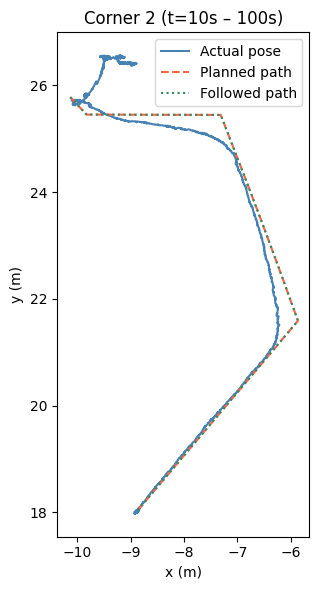

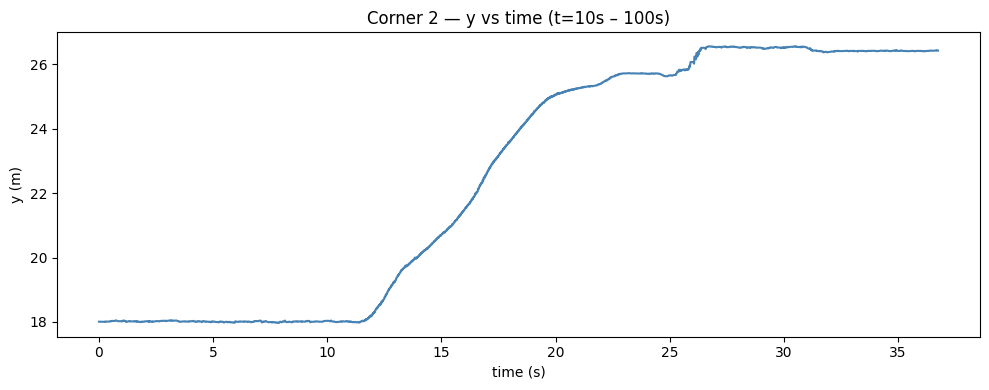

In [11]:

plot_paths(dfs['corner2'], "Corner 2", t_start=10, t_end=T_END)
plot_y_vs_time(dfs['corner2'], "Corner 2", t_start=10, t_end=T_END)


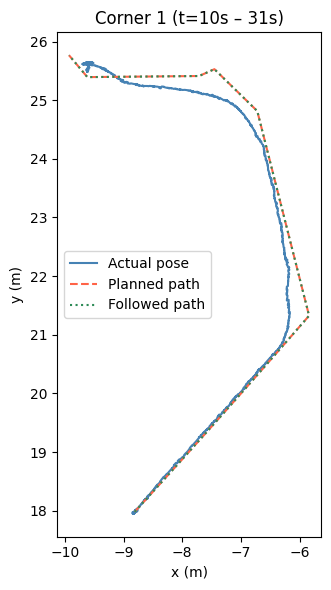

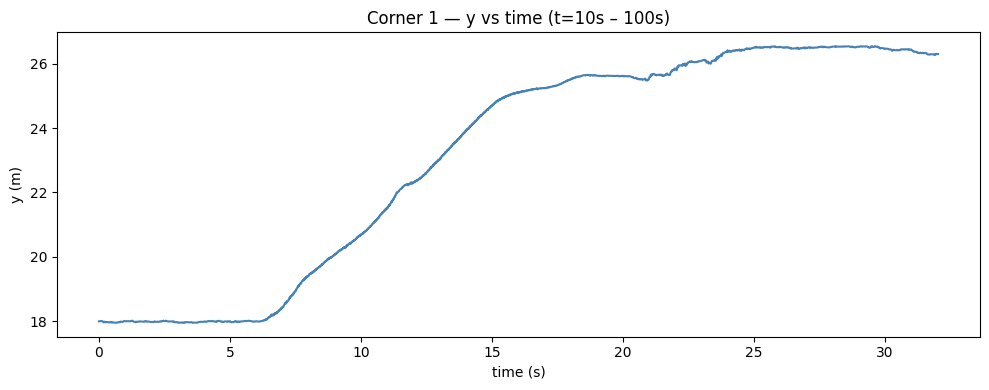

In [32]:

plot_paths(dfs['corner3'], "Corner 1", t_start=10, t_end=31)
plot_y_vs_time(dfs['corner3'], "Corner 1", t_start=10, t_end=T_END)


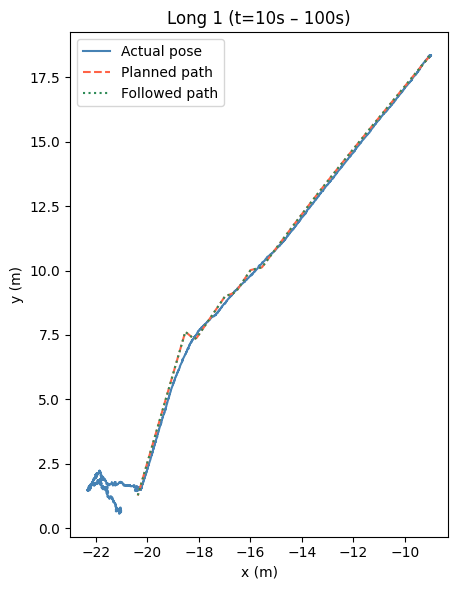

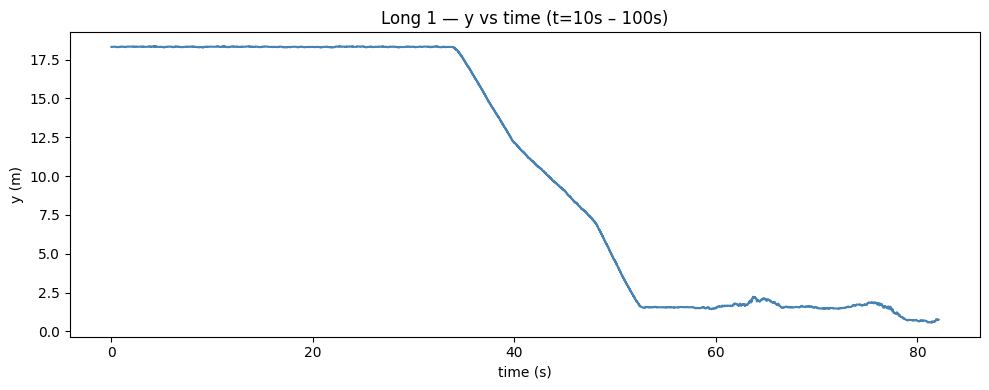

In [13]:

plot_paths(dfs['s1'], "Long 1", t_start=10, t_end=T_END)
plot_y_vs_time(dfs['s1'], "Long 1", t_start=10, t_end=T_END)


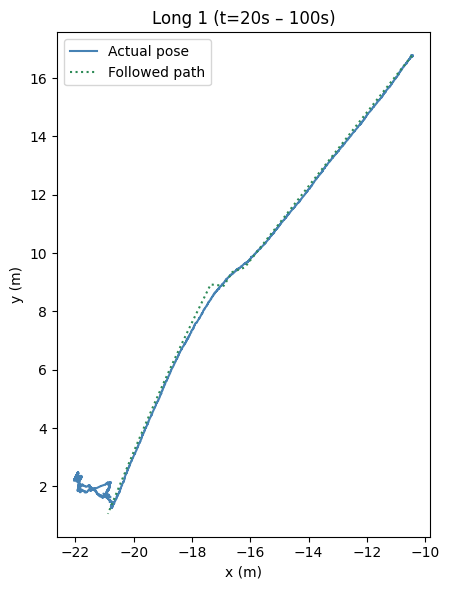

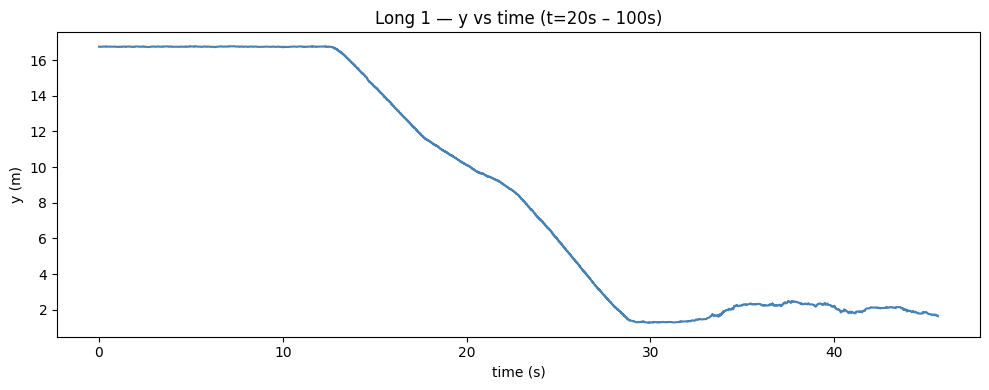

In [33]:

plot_paths(dfs['s2'], "Long 1", t_start=20, t_end=T_END)
plot_y_vs_time(dfs['s2'], "Long 1", t_start=20, t_end=T_END)


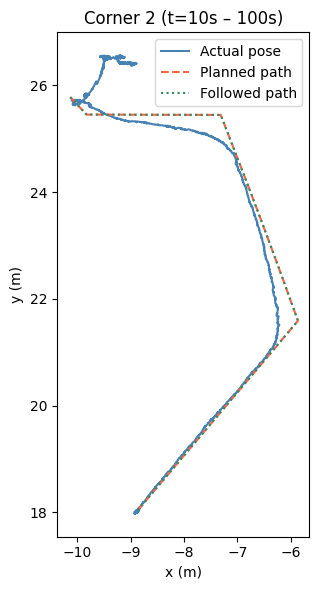

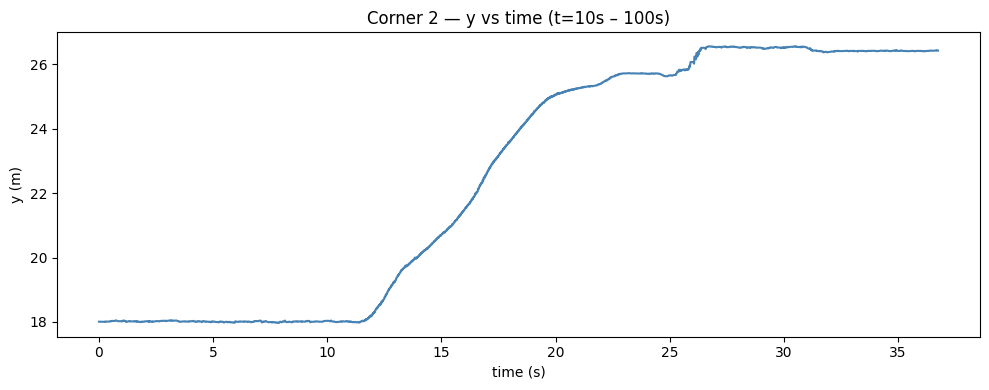

In [15]:

plot_paths(dfs['corner2'], "Corner 2", t_start=10, t_end=T_END)
plot_y_vs_time(dfs['corner2'], "Corner 2", t_start=10, t_end=T_END)


In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cte(df, min_time, max_time, title=None):
    """
    Plot cross-track error over time for a single dataframe between min_time and max_time
    (seconds relative to the start of the trial).

    Assumes:
      - `df` is one of the loaded dataframes from `dfs`
      - `_trim(df, min_time, max_time)` exists
      - `parse_points(...)` exists
      - the dataframe contains:
            topic
            followed_trajectory.path.points
            pf.pose.pose.position.x
            pf.pose.pose.position.y
      - if available, a time column named one of:
            'time', 't', 'timestamp', '__time'
        Otherwise it uses sample index on the x-axis.
    """
    df_trim = _trim(df, min_time, max_time)

    followed_rows = df_trim[df_trim["topic"] == "/followed_trajectory/path"].dropna(
        subset=["followed_trajectory.path.points"]
    )
    if followed_rows.empty:
        raise ValueError("No /followed_trajectory/path data in the requested time window.")

    path_xs, path_ys = parse_points(followed_rows.iloc[0]["followed_trajectory.path.points"])
    if len(path_xs) < 2:
        raise ValueError("Followed path has fewer than 2 points.")

    actual = df_trim[df_trim["topic"] == "/pf/pose"].dropna(
        subset=["pf.pose.pose.position.x", "pf.pose.pose.position.y"]
    )
    if actual.empty:
        raise ValueError("No /pf/pose data in the requested time window.")

    pose_x = actual["pf.pose.pose.position.x"].values
    pose_y = actual["pf.pose.pose.position.y"].values

    cte = _cte_for_pose(pose_x, pose_y, path_xs, path_ys)

    # Try to use a real time column if present
    time_col = None
    for candidate in ["time", "t", "timestamp", "__time"]:
        if candidate in actual.columns:
            time_col = candidate
            break

    if time_col is not None:
        ts = actual[time_col].values
        ts = ts - ts[0]
        xlabel = f"{time_col} (relative)"
    else:
        ts = np.arange(len(cte))
        xlabel = "sample index"

    plt.figure(figsize=(7, 4))
    plt.plot(ts, cte)
    plt.axhline(cte.mean(), linestyle="--", label=f"mean = {cte.mean():.4f} m")
    plt.xlabel(xlabel)
    plt.ylabel("Cross-track error (m)")
    plt.title(title or f"Cross-track Error, {min_time}s to {max_time}s")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return cte

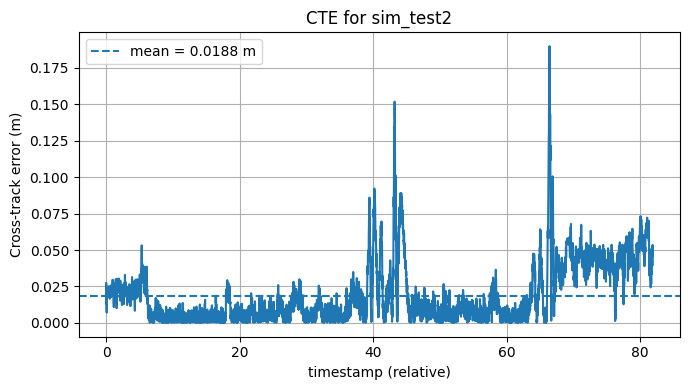

In [26]:
cte_vals = plot_cte(dfs['sim_test2'], min_time=0, max_time=100, title="CTE for sim_test2")

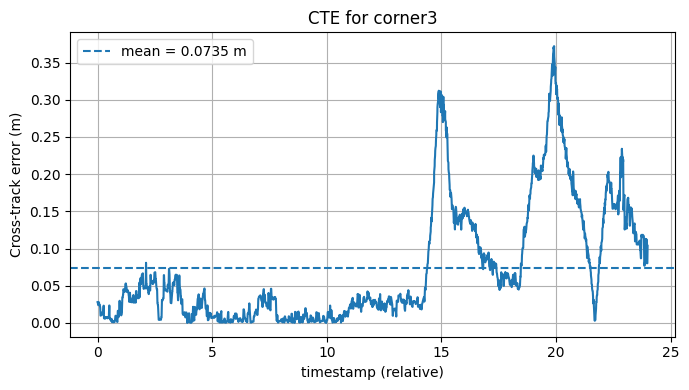

In [27]:
cte_vals = plot_cte(dfs['corner3'], min_time=6, max_time=30, title="CTE for corner3")

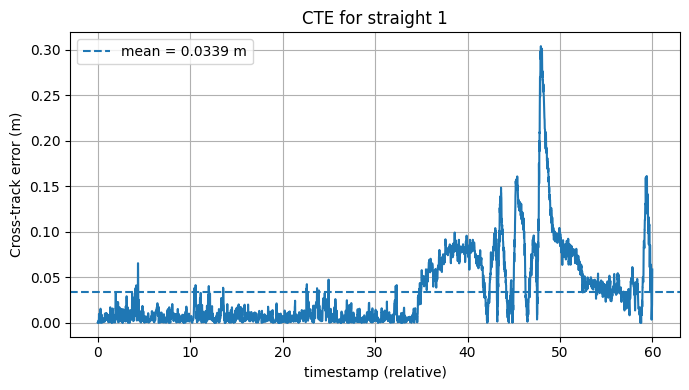

In [38]:
cte_vals = plot_cte(dfs['s1'], min_time=10, max_time=70, title="CTE for straight 1")

In [ ]:
cte_vals = plot_cte(dfs['corner3'], min_time=6, max_time=30, title="CTE for corner3")